In [6]:
import pandas as pd 
import numpy as np 
from sklearn.preprocessing import RobustScaler
from minisom import MiniSom
import os
import sys 

project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
if project_root not in sys.path:
    sys.path.append(project_root)
    
from forecasting.get_forecasting_model import *

In [7]:
processed_dir = os.path.join(project_root, "data", "processed")

# Load data
df = pd.read_csv(os.path.join(processed_dir, "train.csv"))
df= df.copy()
viz = pd.read_csv(os.path.join(processed_dir, "for_visualization.csv"))

df['time'] = pd.to_datetime(df['time'])
viz['time'] = pd.to_datetime(viz['time'])

df['status'] = df['status'].astype(str)

In [8]:
predictor60 = Predictor('rvfl', '60min')
df_agg_60 = predictor60.agg_df(df)
print(df_agg_60.head(5))

                 time        size  Error  No Change  Not Found  Redirected  \
0 1995-07-01 00:00:00  80985486.0    0.0      171.0       24.0       178.0   
1 1995-07-01 01:00:00  81572855.0    0.0      157.0       10.0       114.0   
2 1995-07-01 02:00:00  57160621.0    0.0      132.0       12.0        84.0   
3 1995-07-01 03:00:00  37293218.0    0.0      104.0       16.0        51.0   
4 1995-07-01 04:00:00  29319770.0    0.0       84.0       10.0        39.0   

   Success  anomaly   log_time  
0   3192.0    False  18.209781  
1   2723.0    False  18.217007  
2   2040.0    False  17.861376  
3   1563.0    False  17.434322  
4   1349.0    False  17.193773  


In [9]:
df = df.copy()

df['date'] = df['time'].dt.date
df['hour'] = df['time'].dt.hour

# Tạo matrix: mỗi dòng = 1 ngày, 24 cột giờ
daily_profile = df.pivot_table(
    index='date',
    columns='hour',
    values='size',
    aggfunc='sum'
).fillna(0)

print(daily_profile.head())


hour                0           1           2           3           4   \
date                                                                     
1995-07-01  80985486.0  81572855.0  57160621.0  37293218.0  29319770.0   
1995-07-02  64910973.0  65273627.0  47381988.0  37270620.0  26728977.0   
1995-07-03  84186432.0  62041681.0  49676989.0  60882780.0  41843134.0   
1995-07-04  79281185.0  61365158.0  61225132.0  49653851.0  40871550.0   
1995-07-05  54868907.0  41774494.0  35661231.0  42542845.0  30301760.0   

hour                5           6           7           8           9   ...  \
date                                                                    ...   
1995-07-01  33093160.0  37588204.0  35952119.0  53256289.0  61148331.0  ...   
1995-07-02  32420809.0  44481623.0  30438128.0  39833409.0  62175143.0  ...   
1995-07-03  43092835.0  51140190.0  64200024.0  90391308.0  89216132.0  ...   
1995-07-04  40710445.0  43326123.0  44003239.0  70841457.0  79026708.0  ...   
1995-07

In [10]:
daily_norm = daily_profile.div(daily_profile.sum(axis=1), axis=0)
daily_norm = daily_norm.fillna(0)
print(daily_norm.head())


hour              0         1         2         3         4         5   \
date                                                                     
1995-07-01  0.050064  0.050427  0.035336  0.023054  0.018125  0.020458   
1995-07-02  0.042376  0.042613  0.030933  0.024332  0.017450  0.021165   
1995-07-03  0.040371  0.029752  0.023822  0.029196  0.020065  0.020665   
1995-07-04  0.045447  0.035177  0.035097  0.028464  0.023429  0.023337   
1995-07-05  0.026749  0.020365  0.017385  0.020740  0.014772  0.015722   

hour              6         7         8         9   ...        14        15  \
date                                                ...                       
1995-07-01  0.023237  0.022225  0.032922  0.037801  ...  0.045280  0.063339   
1995-07-02  0.029039  0.019871  0.026005  0.040590  ...  0.053595  0.048145   
1995-07-03  0.024524  0.030787  0.043346  0.042783  ...  0.057953  0.062339   
1995-07-04  0.024836  0.025224  0.040609  0.045301  ...  0.056345  0.065436   
1995-07

In [11]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(daily_norm)

In [12]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)
daily_profile['kmeans_cluster'] = kmeans.fit_predict(X_scaled)

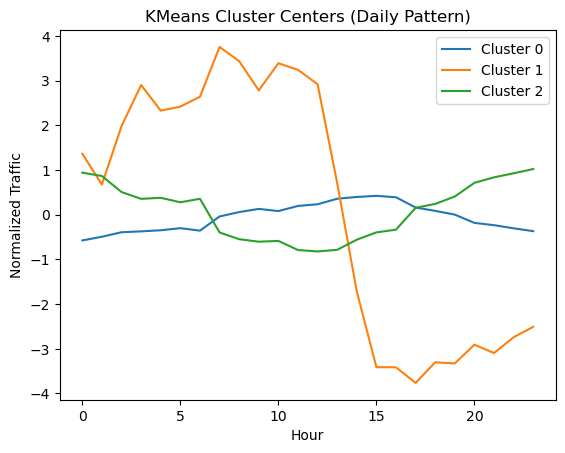

In [13]:
import matplotlib.pyplot as plt

centers = kmeans.cluster_centers_

plt.figure()
for i, center in enumerate(centers):
    plt.plot(range(24), center, label=f'Cluster {i}')

plt.xlabel("Hour")
plt.ylabel("Normalized Traffic")
plt.title("KMeans Cluster Centers (Daily Pattern)")
plt.legend()
plt.show()

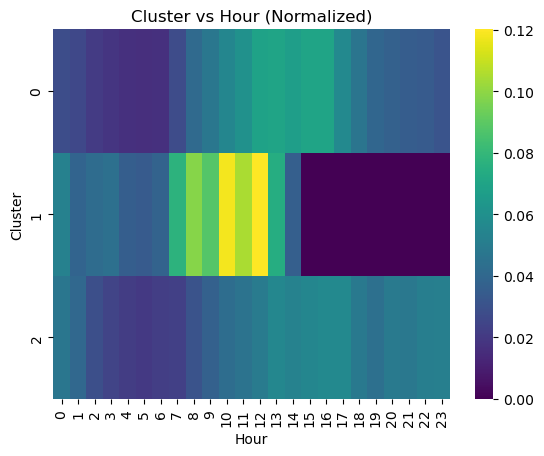

In [14]:
import seaborn as sns

cluster_hour = daily_norm.copy()
cluster_hour['cluster'] = daily_profile['kmeans_cluster']

cluster_mean = cluster_hour.groupby('cluster').mean()

plt.figure()
sns.heatmap(cluster_mean, cmap="viridis")
plt.title("Cluster vs Hour (Normalized)")
plt.xlabel("Hour")
plt.ylabel("Cluster")
plt.show()

In [15]:
from minisom import MiniSom

som = MiniSom(
    x=2, y=2,              # 4 clusters cho gọn
    input_len=X_scaled.shape[1],
    sigma=1.0,
    learning_rate=0.3,
    random_seed=42
)

som.random_weights_init(X_scaled)
som.train_random(X_scaled, 2000)

som_shape = som.get_weights().shape

def get_cluster(x):
    row, col = som.winner(x)
    return row * som_shape[1] + col

daily_profile['som_cluster'] = [get_cluster(x) for x in X_scaled]

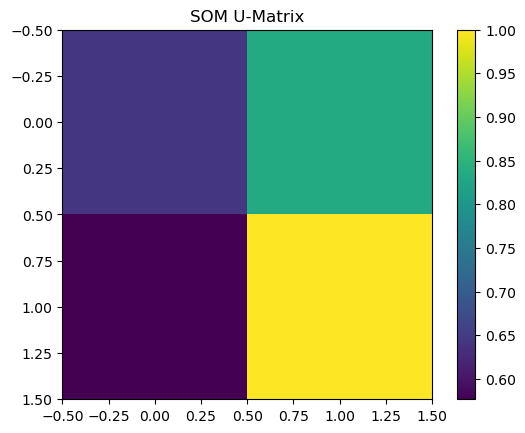

In [16]:
plt.figure()
plt.imshow(som.distance_map(), cmap='viridis')
plt.title("SOM U-Matrix")
plt.colorbar()
plt.show()